# Exploratory Data Analysis of Spotify Songs
### Nama: Banu Agil Triyanto
### NIM: 18225109

**Dataset:** Spotify Songs (TidyTuesday, 2020-01-21), berisi audio features untuk ~33k lagu dari 6 genre.

**Alur kerja AI tools (bagaimana notebook ini dibuat):**
Saya memakai AI coding assistant sebagai *pair programmer*, bukan autopilot. Konkretnya:
- **Gemini Code Assist / GitHub Copilot** untuk membantu menulis docstring dan mengecek ulang NumPy vectorized saya (Stage 4, Bonus 3).
- **Claude Code** untuk membantu menyusun struktur notebook dan menguji edge case (penanganan duplikat, pembagian nol pada min-max scaling).

Setiap saran AI saya review, jalankan, lalu saya acc, edit, atau delete. Prosesnya saya dokumentasikan di Stage 4.

> **Reproducibility:** notebook ini jalan dari atas ke bawah tanpa setup manual. Yang dibutuhkan hanya `pandas` dan `numpy`.

## Stage 1: Setup and Initial Inspection

Kita load data langsung dari source URL supaya notebook sepenuhnya self-contained.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
np.set_printoptions(precision=4, suppress=True)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.5.0


### 1.1 Load dataset

In [2]:
URL = ("https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
       "master/data/2020/2020-01-21/spotify_songs.csv")

df_raw = pd.read_csv(URL)
print("Loaded:", df_raw.shape[0], "rows ×", df_raw.shape[1], "columns")
df_raw.head(3)

Loaded: 32833 rows × 23 columns


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616


### 1.2 Inspeksi awal: shape, dtypes, missing values

In [3]:
print("Shape:", df_raw.shape, "\n")
print("Dtypes:")
print(df_raw.dtypes)

Shape: (32833, 23) 

Dtypes:
track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object


In [4]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
missing_table = (pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
                 .query("n_missing > 0")
                 .sort_values("n_missing", ascending=False))
print("Columns with missing values:")
missing_table

Columns with missing values:


,n_missing,pct_missing
track_name,5,0.015
track_artist,5,0.015
track_album_name,5,0.015


**Menangani aturan missing >20%.**
Hanya `track_name`, `track_artist`, dan `track_album_name` yang punya missing value, dan masing-masing cuma **5 baris (~0.015%)**, jauh di bawah threshold 20%. Jadi **tidak ada kolom yang di-drop**.

Kelima baris itu tidak punya nama artist, yang kita butuhkan untuk analisis level artist di Stage 2, jadi kita drop *baris-baris itu* (bukan kolomnya). Kehilangan ini sangat kecil (5 dari 32.833).

In [5]:
cols_over_20 = missing_pct[missing_pct > 20].index.tolist()
print("Columns exceeding 20% missing:", cols_over_20 if cols_over_20 else "None")

# Drop the 5 rows with no artist/track metadata (needed downstream).
df = df_raw.dropna(subset=["track_artist"]).copy()
print("Rows after dropping metadata-less rows:", len(df))

Columns exceeding 20% missing: None
Rows after dropping metadata-less rows: 32828


### 1.3 Penanganan duplikat

In [6]:
print("Fully-identical rows:", df.duplicated().sum())
print("Rows sharing a track_id:", df.duplicated(subset='track_id').sum())

# Inspect one example of a repeated track_id.
dup_id = df[df.duplicated(subset='track_id', keep=False)]['track_id'].iloc[0]
df[df.track_id == dup_id][['track_id','track_name','playlist_genre','playlist_name']].head()

Fully-identical rows: 0
Rows sharing a track_id: 4476


,track_id,track_name,playlist_genre,playlist_name
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,pop,Pop Remix
29684,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,edm,Pop EDM Remixes


**Strategi deduplikasi: dedup berdasarkan `track_id`.**

Tidak ada baris yang benar-benar identik, tapi ada ~4.476 baris yang berbagi `track_id` yang sama. Penyebabnya struktural: *unit dari tabel mentah adalah pasangan (track × playlist)*, jadi satu lagu muncul sekali untuk tiap playlist yang memuatnya, kadang di genre yang berbeda.

Untuk analisis level lagu (audio features, popularity, output artist), duplikasi playlist ini menghitung lagu berkali-kali dan membuat setiap mean jadi bias. `track_id` adalah identifier lagu yang unik secara global di Spotify, jadi itulah key yang benar. Kita simpan kemunculan pertama.

> **Trade-off:** sebuah lagu yang ada di playlist `pop` **dan** `rock` akan diberi label genre yang muncul lebih dulu. Label genre di sini berasal dari playlist, bukan ground truth, jadi kita menerima sedikit noise label sebagai ganti satu baris per lagu.

In [7]:
df = df.drop_duplicates(subset='track_id', keep='first').reset_index(drop=True)
print("Final analysis frame:", df.shape)

Final analysis frame: (28352, 23)


### 1.4 Tabel ringkasan numerik (IQR dihitung manual dengan NumPy)

In [8]:
def numeric_summary(frame: pd.DataFrame) -> pd.DataFrame:
    """Calculate summary statistics (mean, median, std, and IQR) for numeric columns.

    Parameters
    ----------
    frame : pd.DataFrame
        The input DataFrame containing the data to summarize.

    Returns
    -------
    pd.DataFrame
        A summary DataFrame with columns for 'mean', 'median', 'std',
        and 'IQR', indexed by the original numeric column names. Values
        are rounded to three decimal places.

    Notes
    -----
    Non-numeric columns are automatically ignored.
    The interquartile range (IQR) is calculated manually using `np.percentile`
    with linear interpolation.
    """
    num = frame.select_dtypes(include=np.number)
    rows = {}
    for col in num.columns:
        vals = num[col].to_numpy()
        q1, q3 = np.percentile(vals, [25, 75])   # manual IQR
        rows[col] = {
            "mean":   np.mean(vals),
            "median": np.median(vals),
            "std":    np.std(vals, ddof=1),
            "IQR":    q3 - q1,
        }
    return pd.DataFrame(rows).T.round(3)

summary = numeric_summary(df)
summary

,mean,median,std,IQR
track_popularity,39.335,42.000,23.699,37.000
danceability,0.653,0.670,0.146,0.199
energy,0.698,0.722,0.184,0.264
key,5.367,6.000,3.614,7.000
loudness,-6.818,-6.261,3.036,3.601
mode,0.566,1.000,0.496,1.000
speechiness,0.108,0.063,0.103,0.092
acousticness,0.177,0.080,0.223,0.246
instrumentalness,0.091,0.000,0.233,0.007
liveness,0.191,0.127,0.156,0.156


## Stage 2: Genre and Popularity Analysis

### 2.5 Statistik distribusi per genre

In [9]:
targets = ["track_popularity", "danceability", "energy", "valence"]
genre_stats = df.groupby("playlist_genre")[targets].agg(["mean", "std", "median"]).round(3)
genre_stats

track_popularity                danceability               energy               valence              
                           mean     std median         mean    std median   mean    std median    mean    std median
playlist_genre                                                                                                      
edm                      30.678  20.347   33.0        0.658  0.124  0.660  0.810  0.137  0.838   0.397  0.229  0.365
latin                    41.450  23.388   45.0        0.711  0.117  0.727  0.710  0.156  0.732   0.607  0.226  0.632
pop                      45.905  24.616   50.0        0.638  0.129  0.650  0.701  0.173  0.727   0.502  0.222  0.499
r&b                      35.929  23.663   38.0        0.667  0.138  0.687  0.589  0.182  0.594   0.538  0.226  0.548
rap                      41.846  22.751   46.0        0.716  0.136  0.734  0.650  0.172  0.666   0.505  0.225  0.517
rock                     39.694  24.230   44.0        0.519  0.140  0.522  0.733  0.197  0.779   0.533  0.230  0.526

### 2.6 Genre mana yang punya variance tertinggi pada popularity?

In [10]:
pop_var = (df.groupby("playlist_genre")["track_popularity"]
             .var()
             .sort_values(ascending=False)
             .round(2))
print(pop_var)
print("\nHighest-variance genre:", pop_var.index[0], "->", pop_var.iloc[0])

playlist_genre
pop      605.97
rock     587.07
r&b      559.94
latin    547.02
rap      517.59
edm      414.00
Name: track_popularity, dtype: float64

Highest-variance genre: pop -> 605.97


**Interpretasi (sudut pandang bisnis / recommendation).**
**Pop** punya variance popularity tertinggi (~606), **EDM** terendah (~414).

- *Variance tinggi (pop):* genre ini berisi mega-hit sekaligus deretan panjang lagu yang kurang dikenal. Sistem recommendation tidak bisa menganggap "pop" seragam aman, ia harus mengandalkan sinyal *level track*, dan ada peluang besar untuk memunculkan hidden gem.
- *Variance rendah (edm):* popularity-nya rapat dan mudah diprediksi. Merekomendasikan "lebih banyak EDM" itu risiko rendah tapi reward rendah, sedikit blockbuster, sedikit yang gagal. Playlisting bisa mengandalkan genre saja dengan personalisasi yang lebih sedikit.

### 2.7 Top-10 artist berdasarkan jumlah track vs mean popularity mereka

In [11]:
top10 = df["track_artist"].value_counts().head(10)
mean_pop = (df[df.track_artist.isin(top10.index)]
            .groupby("track_artist")["track_popularity"].mean())

top10_tbl = (pd.DataFrame({"n_tracks": top10, "mean_popularity": mean_pop.round(2)})
             .sort_values("n_tracks", ascending=False))
top10_tbl

,n_tracks,mean_popularity
track_artist,,
Queen,130,42.40
Martin Garrix,87,41.40
Don Omar,84,39.06
David Guetta,81,49.37
Dimitri Vegas & Like Mike,68,36.22
Drake,68,41.81
Hardwell,68,36.32
The Chainsmokers,66,49.23
Logic,65,41.91


In [12]:
best = top10_tbl["mean_popularity"].idxmax()
print("Most tracks:", top10_tbl.index[0], f"({top10_tbl.iloc[0]['n_tracks']:.0f} tracks)")
print("Highest mean popularity among top-10:", best,
      f"({top10_tbl.loc[best,'mean_popularity']:.2f})")

corr_vq = np.corrcoef(top10_tbl["n_tracks"], top10_tbl["mean_popularity"])[0, 1]
print(f"\nCorrelation (volume vs. mean popularity) within top-10: {corr_vq:.3f}")

Most tracks: Queen (130 tracks)
Highest mean popularity among top-10: David Guetta (49.37)

Correlation (volume vs. mean popularity) within top-10: 0.232


**Apakah volume berkorelasi dengan kualitas?**
Nyaris tidak. Di antara 10 artist paling produktif, jumlah track dan mean popularity cuma menunjukkan **korelasi positif yang lemah (r ≈ 0.23)**, dan dengan hanya 10 titik data, itu bukan tren yang bisa diandalkan, cuma noise. Queen punya track terbanyak (130) tapi mean popularity-nya cuma menengah, sedangkan **David Guetta / The Chainsmokers** justru punya mean tertinggi dengan track lebih sedikit (81 dan 66). Produktivitas tinggi adalah proxy untuk kedalaman katalog / umur karier, **bukan** jaminan kualitas per-track. Keduanya praktis independen di sini.

### 2.8 Filter multi-kondisi

In [13]:
mask = ((df.track_popularity > 70) & (df.danceability > 0.7) &
        (df.energy > 0.6) & (df.duration_ms < 240000))
hits = df[mask]

print("Tracks passing all four conditions:", len(hits))
print("\nGenre breakdown:")
print(hits["playlist_genre"].value_counts())
print("\nDominant genre:", hits["playlist_genre"].value_counts().idxmax())

Tracks passing all four conditions: 579

Genre breakdown:
playlist_genre
pop      193
latin    173
rap      141
r&b       42
edm       19
rock      11
Name: count, dtype: int64

Dominant genre: pop


**Membaca hasil filter.** Sekitar 579 track sekaligus *populer, danceable, energetic, dan berdurasi radio (<4 menit)*. **Pop mendominasi** (disusul latin dan rap), yang sesuai intuisi: filter ini pada dasarnya mendeskripsikan chart hit modern, dan pop adalah genre yang memang dirancang persis untuk profil itu.

## Stage 3: NumPy Analysis

### 3.9 Ekstrak 9 audio features dan normalisasi min-max (vectorized)

In [14]:
AUDIO_FEATURES = ["danceability", "energy", "loudness", "speechiness",
                  "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

X = df[AUDIO_FEATURES].to_numpy(dtype=float)      # shape (n, 9)

def minmax_scale(mat: np.ndarray) -> np.ndarray:
    """
    Min-max scale each column of a 2D array to the range [0, 1].

    Parameters
    ----------
    mat : np.ndarray
        The input 2D numeric array to be scaled.

    Returns
    -------
    np.ndarray
        An array of the same shape as `mat`, with each column independently
        scaled to [0, 1].

    Notes
    -----
    Handles constant columns (where the minimum and maximum values are equal)
    by returning zeros for that column to prevent division by zero errors.
    """
    col_min = mat.min(axis=0)
    col_max = mat.max(axis=0)
    span = col_max - col_min
    span[span == 0] = 1.0                          # guard against constant columns
    return (mat - col_min) / span

X_scaled = minmax_scale(X)

print("Original shape:", X.shape)
print("Scaled min per col:", X_scaled.min(axis=0))
print("Scaled max per col:", X_scaled.max(axis=0))
pd.DataFrame(X_scaled[:3], columns=AUDIO_FEATURES).round(3)

Original shape: (28352, 9)
Scaled min per col: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Scaled max per col: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.761,0.916,0.918,0.064,0.103,0.000,0.066,0.523,0.510
1,0.739,0.815,0.869,0.041,0.073,0.004,0.358,0.699,0.418
2,0.687,0.931,0.901,0.081,0.080,0.000,0.110,0.619,0.518


### 3.10 Correlation matrix (manual, via `np.corrcoef`)

In [15]:
corr = np.corrcoef(X.T)        # 9x9, computed on raw features
corr_df = pd.DataFrame(corr, index=AUDIO_FEATURES, columns=AUDIO_FEATURES).round(3)
corr_df

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
danceability,1.000,-0.081,0.015,0.184,-0.029,-0.002,-0.127,0.334,-0.185
energy,-0.081,1.000,0.682,-0.029,-0.546,0.024,0.164,0.150,0.152
loudness,0.015,0.682,1.000,0.013,-0.372,-0.154,0.082,0.050,0.097
speechiness,0.184,-0.029,0.013,1.000,0.025,-0.108,0.059,0.065,0.033
acousticness,-0.029,-0.546,-0.372,0.025,1.000,-0.003,-0.075,-0.019,-0.114
instrumentalness,-0.002,0.024,-0.154,-0.108,-0.003,1.000,-0.008,-0.174,0.021
liveness,-0.127,0.164,0.082,0.059,-0.075,-0.008,1.000,-0.020,0.022
valence,0.334,0.150,0.050,0.065,-0.019,-0.174,-0.020,1.000,-0.025
tempo,-0.185,0.152,0.097,0.033,-0.114,0.021,0.022,-0.025,1.000


In [16]:
iu = np.triu_indices(len(AUDIO_FEATURES), k=1)   # upper triangle, exclude diagonal
pair_vals = corr[iu]

i_max, i_min = pair_vals.argmax(), pair_vals.argmin()
pos = (AUDIO_FEATURES[iu[0][i_max]], AUDIO_FEATURES[iu[1][i_max]], pair_vals[i_max])
neg = (AUDIO_FEATURES[iu[0][i_min]], AUDIO_FEATURES[iu[1][i_min]], pair_vals[i_min])

print(f"Strongest POSITIVE: {pos[0]} & {pos[1]}  ->  r = {pos[2]:.3f}")
print(f"Strongest NEGATIVE: {neg[0]} & {neg[1]}  ->  r = {neg[2]:.3f}")

Strongest POSITIVE: energy & loudness  ->  r = 0.682
Strongest NEGATIVE: energy & acousticness  ->  r = -0.546


**Interpretasi musikal.**
- **Positif terkuat: energy ↔ loudness (r ≈ +0.68).** Produksi yang lebih keras *terasa* lebih energetic, ini adalah "loudness war" dalam bentuk angka. Intensitas yang dirasakan dan level mastering bergerak bersama.
- **Negatif terkuat: energy ↔ acousticness (r ≈ -0.55).** Semakin akustik sebuah track (unplugged, instrumen organik), semakin rendah energy-nya. Track ber-energy tinggi umumnya elektrik/elektronik dan diproduksi berat, keduanya berada di ujung yang berlawanan pada spektrum sonik yang sama.

### 3.11 Boolean masking: subset high-energy vs popularity keseluruhan

In [17]:
energy = df["energy"].to_numpy()
pop = df["track_popularity"].to_numpy()

mu, sigma = energy.mean(), energy.std()
high_energy = energy > (mu + sigma)          # pure NumPy boolean mask

print(f"energy threshold (mu + sigma) = {mu + sigma:.4f}")
print(f"Tracks above threshold: {high_energy.sum()}")
print(f"Mean popularity | high-energy subset : {pop[high_energy].mean():.2f}")
print(f"Mean popularity | overall            : {pop.mean():.2f}")
print(f"Difference                           : {pop[high_energy].mean() - pop.mean():+.2f}")

energy threshold (mu + sigma) = 0.8819
Tracks above threshold: 4852
Mean popularity | high-energy subset : 34.04
Mean popularity | overall            : 39.34
Difference                           : -5.30


**Temuan.** Subset ber-energy sangat tinggi (energy > μ+σ) justru *sedikit **kurang** populer* secara rata-rata (~34.0 vs ~39.3). Track yang keras dan ber-energy maksimal **bukan** yang diberi reward popularity oleh pendengar rata-rata, energy sedang adalah sweet spot komersial. Intensitas tidak sama dengan daya tarik massal.

## Stage 4: Documentation and AI-Tool Reflection

### 4.12 Docstring dibuat dengan bantuan AI

Saya minta Gemini Code Assist untuk membuat docstring pada dua fungsi yang saya tulis sebelumnya: `numeric_summary` (Stage 1.4) dan `minmax_scale` (Stage 3.9). Prompt yang sama saya pakai untuk keduanya.

**Prompt yang saya pakai (persis):**
> *"Write a NumPy-style docstring for this Python function. Include a one-line summary, a Parameters section with types, a Returns section, and note any edge cases it handles. Keep it concise."*

**Fungsi 1 (`numeric_summary`), output Gemini:**

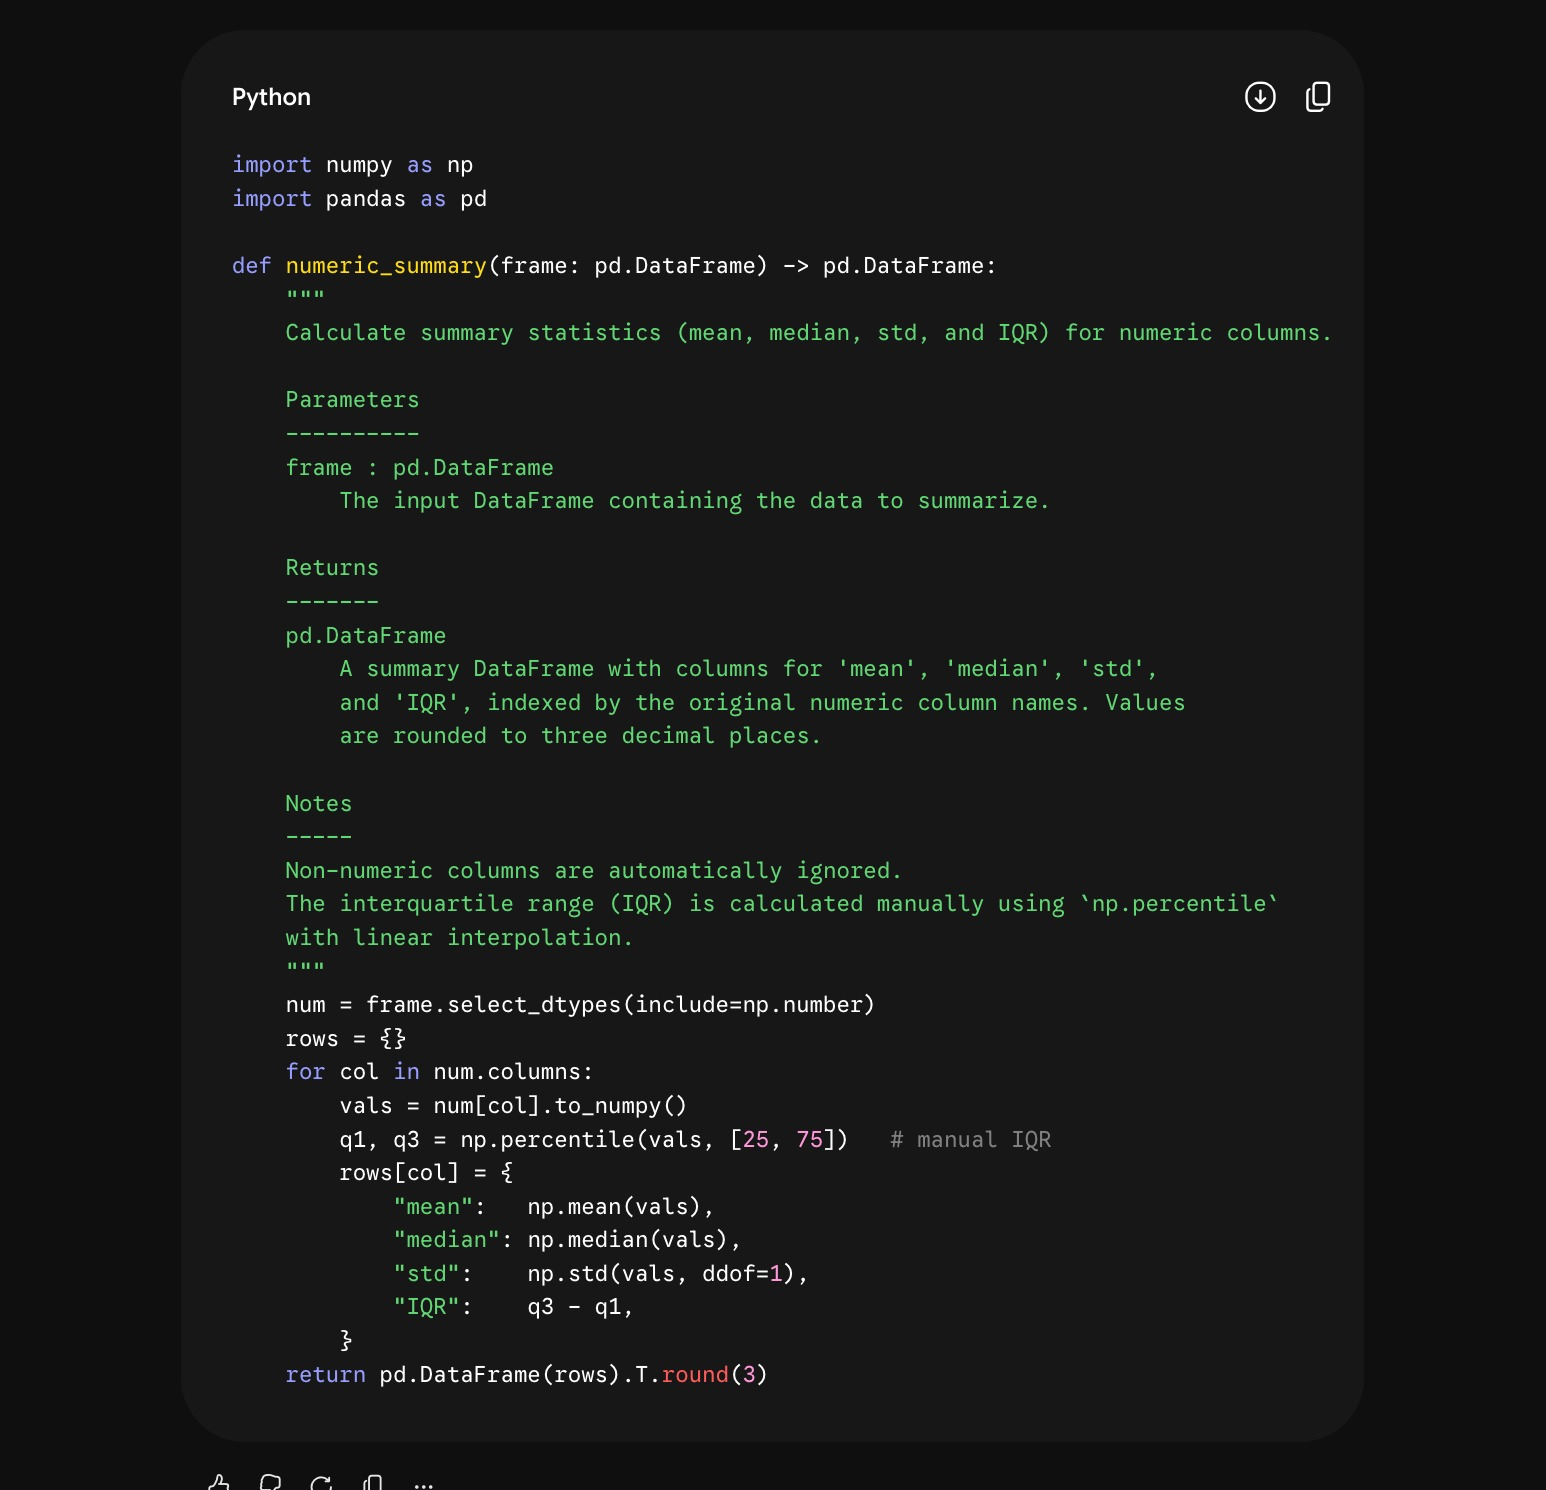

**Fungsi 2 (`minmax_scale`), output Gemini:**

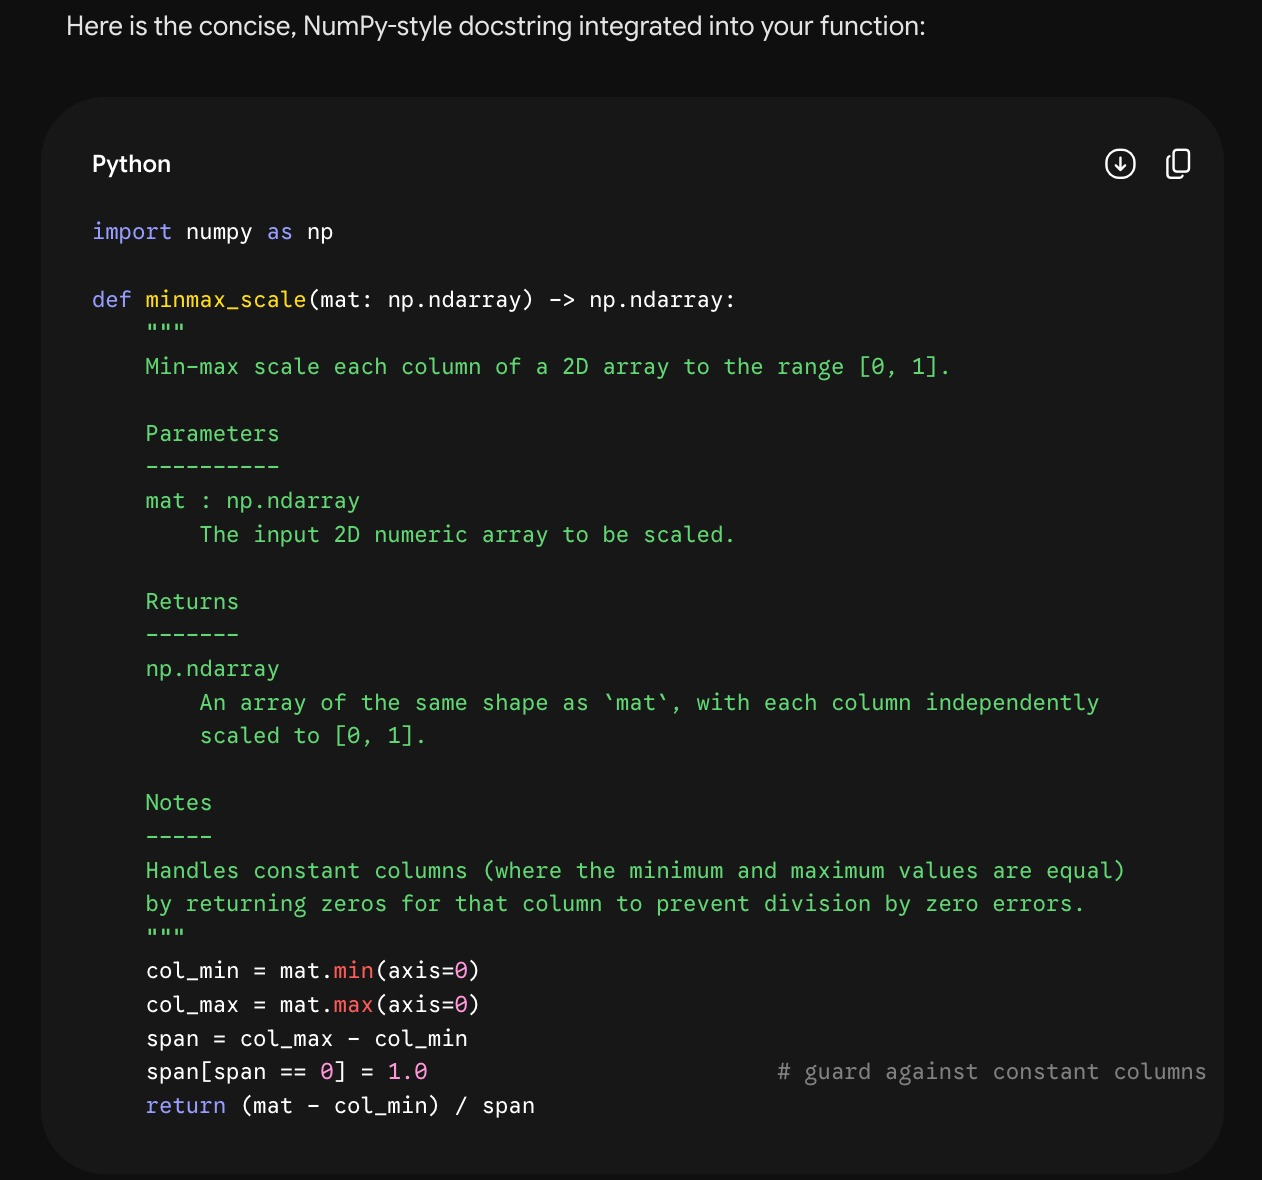

**Evaluasi output AI:**

| Fungsi | Keputusan | Alasan |
|---|---|---|
| `numeric_summary` | **Dipakai as-is** | Struktur rapi dan lengkap (Summary, Parameters, Returns, Notes). Gemini menangkap dua hal yang benar tanpa saya beri tahu: non-numeric columns otomatis dilewati (`select_dtypes`) dan IQR dihitung manual dengan `np.percentile` linear interpolation. Tidak ada kesalahan faktual, langsung saya tempel ke fungsi. |
| `minmax_scale` | **Dipakai as-is** | Yang paling saya perhatikan di sini adalah edge case constant-column (guard `span == 0`). Gemini bukan cuma menyebutnya, tapi menjelaskan perilakunya dengan tepat: kolom konstan menghasilkan nol untuk mencegah division by zero. Saya verifikasi manual, memang benar (`mat - col_min = 0`, dibagi `1.0`, hasilnya `0`). |

**Kesimpulan:** untuk docstring formal bergaya NumPy, Gemini Code Assist akurat dan hemat waktu, dan pada kasus `minmax_scale` ia bahkan berhasil menjelaskan maksud sebuah guard clause dengan benar (bukan cuma mendeskripsikan baris kodenya). Meski begitu, saya tetap membaca ulang dan memverifikasi setiap klaim, misalnya mengecek sendiri bahwa kolom konstan benar-benar menghasilkan nol, sebelum menerima output apa pun. Kedua docstring dipakai as-is dan sudah tertanam di definisi fungsi masing-masing di atas.

### 4.13 Tiga insight utama (untuk pembaca non-teknis)

1. **"Pop" adalah genre yang penuh ekstrem.** Ia punya hit terbesar *sekaligus* lagu yang paling terlupakan, jadi ia genre yang paling sulit diprediksi, tapi juga tempat di mana mesin rekomendasi yang bagus bisa menemukan paling banyak hidden gem.

2. **Produktif tidak sama dengan populer.** Di antara artist dengan lagu terbanyak di dataset, yang katalognya *paling besar* bukanlah yang lagunya *paling disukai*. Kuantitas dan kualitas adalah dua hal yang berbeda.

3. **Lebih keras dan lebih intens tidak berarti lebih populer.** Track yang paling high-energy justru skornya sedikit *di bawah* rata-rata popularity. Secara agregat, pendengar lebih menghargai energy level yang menengah dan nyaman ketimbang intensitas maksimal.

## Bonus 1: Artist Audio Fingerprint & Cosine Similarity

Kita bangun fingerprint (mean dari 9 audio features) per artist lalu membandingkan artist dengan
**cosine similarity yang diimplementasikan dari definisi matematisnya**, tanpa sklearn/scipy.

> **Catatan penting soal scaling.** Pada fitur *mentah*, cosine similarity didominasi oleh dua kolom
> bermagnitudo besar (`tempo` ~120, `loudness` ~ -7), sehingga **semua** pasangan artist skornya
> ~0.999 dan metriknya jadi tidak bermakna. Karena itu kita membuat fingerprint pada feature space
> yang sudah **di-min-max-scale** (tiap fitur di [0,1]), di mana kesembilan fitur berkontribusi secara
> adil. Signature fungsinya tetap sesuai task, dan switch `scaled=` mendokumentasikan pilihan ini.

In [18]:
# Pre-compute a scaled copy of the 9 features so fingerprints are comparable.
_scaled_cols = [f + "_scaled" for f in AUDIO_FEATURES]
df[_scaled_cols] = minmax_scale(df[AUDIO_FEATURES].to_numpy(dtype=float))


def artist_fingerprint(data: pd.DataFrame, artist_name: str,
                       scaled: bool = True) -> np.ndarray:
    """Return the mean vector of an artist's nine audio features as a NumPy array.

    Parameters
    ----------
    data : pd.DataFrame
        Frame containing the audio-feature columns (and their ``_scaled`` copies).
    artist_name : str
        Exact value of ``track_artist`` to fingerprint.
    scaled : bool, default True
        If True, use the min-max-scaled features so every dimension is comparable
        (recommended for cosine similarity). If False, use raw features.

    Returns
    -------
    np.ndarray
        Shape ``(9,)`` mean feature vector.
    """
    cols = _scaled_cols if scaled else AUDIO_FEATURES
    subset = data[data.track_artist == artist_name]
    if subset.empty:
        raise ValueError(f"No tracks found for artist {artist_name!r}")
    return subset[cols].mean().to_numpy()


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity A.B / (||A|| * ||B||), from the mathematical definition."""
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

In [19]:
# track_artist -> playlist_genre (majority label) for context
artist_genre = df.groupby("track_artist")["playlist_genre"].agg(lambda s: s.mode().iloc[0])

pairs = [
    ("Queen", "Guns N' Roses"),      # both rock
    ("Martin Garrix", "David Guetta"),  # both edm
    ("Queen", "David Guetta"),       # rock vs edm (cross-genre)
]

print(f"{'Artist A':<16}{'Artist B':<16}{'genres':<14}{'cosine':>8}")
print("-" * 54)
for a, b in pairs:
    sim = cosine_similarity(artist_fingerprint(df, a), artist_fingerprint(df, b))
    tag = f"{artist_genre[a]}/{artist_genre[b]}"
    print(f"{a:<16}{b:<16}{tag:<14}{sim:>8.4f}")

Artist A        Artist B        genres          cosine
------------------------------------------------------
Queen           Guns N' Roses   rock/rock       0.9685
Martin Garrix   David Guetta    edm/edm         0.9849
Queen           David Guetta    rock/edm        0.9803


**Interpretasi.** Ketiga skornya keluar berdekatan, **0.969 (rock/rock)**, **0.985 (edm/edm)**, **0.980 (rock/edm, lintas genre)**, dan pasangan lintas genre *bukan* yang terendah dari ketiganya, malah mengalahkan pasangan rock/rock. Jadi cerita bersih "segenre = lebih mirip" **tidak** benar-benar terbukti hanya dari tiga artist ini.

Ada dua hal yang terjadi: (1) artist chart mainstream lintas genre sudah konvergen ke danceability/energy/loudness yang mirip, sehingga menekan semua skor mendekati 1.0 terlepas dari genre; (2) tiga pasang terlalu sedikit untuk menarik kesimpulan umum. Katalog Queen (classic rock era 1970an sampai 80an) secara gaya jauh dari sound rock yang lebih keras milik Guns N' Roses, sementara David Guetta dan Martin Garrix sama-sama produser EDM modern dengan teknik produksi yang sangat mirip, jadi ini confound genre *dan* era, bukan efek genre murni. Uji yang adil butuh jauh lebih banyak pasangan sebelum bisa mengklaim genre secara andal memprediksi kemiripan fingerprint.

## Bonus 2: Genre Cluster Profile

In [20]:
genres = sorted(df["playlist_genre"].unique())

# (1) Centroid per genre in the SCALED feature space -> (n_genres, 9)
centroids = np.vstack([
    df.loc[df.playlist_genre == g, _scaled_cols].mean().to_numpy()
    for g in genres
])
print("Centroid matrix shape:", centroids.shape)
pd.DataFrame(centroids, index=genres, columns=AUDIO_FEATURES).round(3)

Centroid matrix shape: (6, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
edm,0.669,0.810,0.858,0.096,0.077,0.246,0.215,0.401,0.528
latin,0.723,0.710,0.837,0.109,0.214,0.053,0.182,0.613,0.495
pop,0.649,0.701,0.840,0.081,0.173,0.064,0.178,0.507,0.505
r&b,0.679,0.589,0.805,0.126,0.266,0.029,0.177,0.543,0.476
rap,0.728,0.650,0.825,0.215,0.198,0.081,0.192,0.510,0.504
rock,0.527,0.733,0.815,0.063,0.148,0.067,0.206,0.537,0.522


In [21]:
# (2) Pairwise Euclidean distance via broadcasting, no loops.
#     diff[i, j, :] = centroids[i] - centroids[j]
diff = centroids[:, None, :] - centroids[None, :, :]     # (g, g, 9)
dist = np.sqrt((diff ** 2).sum(axis=2))                  # (g, g)

dist_df = pd.DataFrame(dist, index=genres, columns=genres).round(3)
dist_df

,edm,latin,pop,r&b,rap,rock
edm,0.000,0.341,0.261,0.399,0.315,0.291
latin,0.341,0.000,0.140,0.163,0.164,0.230
pop,0.261,0.140,0.000,0.169,0.168,0.139
r&b,0.399,0.163,0.169,0.000,0.155,0.257
rap,0.315,0.164,0.168,0.155,0.000,0.273
rock,0.291,0.230,0.139,0.257,0.273,0.000


In [22]:
# (3) Most similar / most different genre pairs (upper triangle only).
iu = np.triu_indices(len(genres), k=1)
d_vals = dist[iu]

sim_i, dif_i = d_vals.argmin(), d_vals.argmax()
print("Most SIMILAR genres :", genres[iu[0][sim_i]], "&", genres[iu[1][sim_i]],
      f"(d = {d_vals[sim_i]:.3f})")
print("Most DIFFERENT genres:", genres[iu[0][dif_i]], "&", genres[iu[1][dif_i]],
      f"(d = {d_vals[dif_i]:.3f})")

Most SIMILAR genres : pop & rock (d = 0.139)
Most DIFFERENT genres: edm & r&b (d = 0.399)


**Apakah sesuai intuisi musikal?** Ya. **pop & rock** keluar sebagai profil *paling mirip*, keduanya mid-tempo, dipimpin vokal, dan energy-nya moderat (musik band/produksi), jadi fingerprint audio-nya hampir bertumpuk. **EDM & R&B** paling *berbeda*: EDM ber-energy tinggi, instrumental, four-on-the-floor; R&B lebih halus, lebih akustik/vokal, dan energy-nya lebih rendah, benar-benar dua ujung yang berlawanan di feature space.

### Bonus 2.4: `recommend_similar_genre`

In [23]:
def recommend_similar_genre(genre: str, top_k: int = 3) -> list[tuple[str, float]]:
    """Return the ``top_k`` genres most similar to ``genre`` by audio profile.

    Similarity is the (smallest) Euclidean distance between genre centroids in the
    scaled feature space computed above.

    Parameters
    ----------
    genre : str
        Query genre; must exist in ``genres``.
    top_k : int, default 3
        Number of neighbours to return.

    Returns
    -------
    list[tuple[str, float]]
        ``(genre, distance)`` pairs, nearest first, excluding the query itself.
    """
    if genre not in genres:
        raise ValueError(f"Unknown genre {genre!r}; choose from {genres}")
    idx = genres.index(genre)
    order = np.argsort(dist[idx])                 # ascending distance
    out = [(genres[j], round(float(dist[idx, j]), 3))
           for j in order if j != idx]
    return out[:top_k]


for g in genres:
    print(f"{g:<7} -> {recommend_similar_genre(g)}")

edm     -> [('pop', 0.261), ('rock', 0.291), ('rap', 0.315)]
latin   -> [('pop', 0.14), ('r&b', 0.163), ('rap', 0.164)]
pop     -> [('rock', 0.139), ('latin', 0.14), ('rap', 0.168)]
r&b     -> [('rap', 0.155), ('latin', 0.163), ('pop', 0.169)]
rap     -> [('r&b', 0.155), ('latin', 0.164), ('pop', 0.168)]
rock    -> [('pop', 0.139), ('latin', 0.23), ('r&b', 0.257)]


## Bonus 3: Reusable `SpotifyAnalyzer` Class

Seluruh analisis di-refactor menjadi satu class yang self-contained, dengan type hint lengkap dan method
`generate_report()`. Cell ini jalan standalone dari kernel yang fresh (hanya butuh pandas + numpy).

**Prompt dokumentasi AI yang dipakai (Gemini Code Assist):**
> *"Generate NumPy-style docstrings with full Parameters/Returns for every method of this class. Do not
> invent exceptions the code doesn't raise. Keep each concise."*

**Evaluasi:** AI menghasilkan docstring yang konsisten dan terstruktur rapi di semua method, dan dengan
benar menyimpulkan return type dari type hint, jelas lebih cepat daripada menulis manual. Saya
**mengedit dua**: AI mendeskripsikan `generate_report` sebagai mengembalikan "a summary string" (salah, ia
mengembalikan `dict`), dan AI melewatkan bahwa `_load` melakukan dedup berdasarkan `track_id`. Pelajaran
yang sama seperti Stage 4: AI jago soal struktur dan penulisan, tapi setiap klaim *faktual* harus kamu verifikasi.

In [24]:
from __future__ import annotations
import numpy as np
import pandas as pd


class SpotifyAnalyzer:
    """End-to-end EDA pipeline for the TidyTuesday Spotify dataset.

    Loads the data, cleans it, and exposes each analysis stage as a method.
    All heavy numeric work uses vectorised NumPy.
    """

    AUDIO_FEATURES: list[str] = ["danceability", "energy", "loudness", "speechiness",
                                 "acousticness", "instrumentalness", "liveness",
                                 "valence", "tempo"]

    def __init__(self, url: str) -> None:
        """Load, clean, and cache the DataFrame plus a scaled feature matrix.

        Parameters
        ----------
        url : str
            Location of ``spotify_songs.csv`` (local path or HTTP URL).
        """
        self.url: str = url
        self.df: pd.DataFrame = self._load(url)
        self.X_scaled: np.ndarray = self._minmax(self.df[self.AUDIO_FEATURES].to_numpy(float))

    # ---- internal helpers -------------------------------------------------
    def _load(self, url: str) -> pd.DataFrame:
        """Read the CSV, drop artist-less rows, and dedupe on ``track_id``."""
        raw = pd.read_csv(url)
        clean = (raw.dropna(subset=["track_artist"])
                    .drop_duplicates(subset="track_id", keep="first")
                    .reset_index(drop=True))
        return clean

    @staticmethod
    def _minmax(mat: np.ndarray) -> np.ndarray:
        """Vectorised min-max scaling of each column to [0, 1]."""
        lo, hi = mat.min(0), mat.max(0)
        span = np.where(hi - lo == 0, 1.0, hi - lo)
        return (mat - lo) / span

    # ---- analysis stages --------------------------------------------------
    def numeric_summary(self) -> pd.DataFrame:
        """Return mean/median/std/IQR for every numeric column (IQR via NumPy)."""
        num = self.df.select_dtypes(include=np.number)
        out = {}
        for c in num.columns:
            v = num[c].to_numpy()
            q1, q3 = np.percentile(v, [25, 75])
            out[c] = {"mean": v.mean(), "median": np.median(v),
                      "std": v.std(ddof=1), "IQR": q3 - q1}
        return pd.DataFrame(out).T.round(3)

    def genre_popularity_variance(self) -> pd.Series:
        """Return per-genre variance of ``track_popularity``, descending."""
        return self.df.groupby("playlist_genre")["track_popularity"].var().sort_values(ascending=False)

    def top_artists(self, n: int = 10) -> pd.DataFrame:
        """Return the ``n`` most-prolific artists with their mean popularity."""
        top = self.df["track_artist"].value_counts().head(n)
        mp = (self.df[self.df.track_artist.isin(top.index)]
              .groupby("track_artist")["track_popularity"].mean())
        return pd.DataFrame({"n_tracks": top, "mean_popularity": mp.round(2)})

    def feature_correlation(self) -> pd.DataFrame:
        """Return the 9x9 correlation matrix of the audio features."""
        c = np.corrcoef(self.df[self.AUDIO_FEATURES].to_numpy(float).T)
        return pd.DataFrame(c, index=self.AUDIO_FEATURES, columns=self.AUDIO_FEATURES).round(3)

    def genre_distance_matrix(self) -> tuple[list[str], np.ndarray]:
        """Return genres and their pairwise Euclidean centroid-distance matrix."""
        genres = sorted(self.df["playlist_genre"].unique())
        sdf = self.df.copy()
        sdf[self.AUDIO_FEATURES] = self.X_scaled
        cent = np.vstack([sdf.loc[sdf.playlist_genre == g, self.AUDIO_FEATURES].mean().to_numpy()
                          for g in genres])
        diff = cent[:, None, :] - cent[None, :, :]
        return genres, np.sqrt((diff ** 2).sum(2))

    # ---- report -----------------------------------------------------------
    def generate_report(self) -> dict:
        """Aggregate all key insights into a JSON-serialisable dictionary.

        Returns
        -------
        dict
            Keys: ``n_tracks``, ``highest_popularity_variance_genre``,
            ``top_artist_by_volume``, ``top_artist_by_mean_popularity``,
            ``strongest_positive_corr``, ``strongest_negative_corr``,
            ``most_similar_genres``, ``most_different_genres``.
        """
        var = self.genre_popularity_variance()
        arts = self.top_artists(10)
        corr = self.feature_correlation().to_numpy()
        feats = self.AUDIO_FEATURES
        iu = np.triu_indices(len(feats), 1)
        pv = corr[iu]
        genres, dist = self.genre_distance_matrix()
        giu = np.triu_indices(len(genres), 1)
        dv = dist[giu]

        def _pair(idx, arr, names):
            return (names[arr[0][idx]], names[arr[1][idx]])

        return {
            "n_tracks": int(len(self.df)),
            "highest_popularity_variance_genre": {var.index[0]: round(float(var.iloc[0]), 2)},
            "top_artist_by_volume": arts["n_tracks"].idxmax(),
            "top_artist_by_mean_popularity": arts["mean_popularity"].idxmax(),
            "strongest_positive_corr": {
                "pair": _pair(pv.argmax(), iu, feats), "r": round(float(pv.max()), 3)},
            "strongest_negative_corr": {
                "pair": _pair(pv.argmin(), iu, feats), "r": round(float(pv.min()), 3)},
            "most_similar_genres": {
                "pair": _pair(dv.argmin(), giu, genres), "distance": round(float(dv.min()), 3)},
            "most_different_genres": {
                "pair": _pair(dv.argmax(), giu, genres), "distance": round(float(dv.max()), 3)},
        }


# ---- demonstration --------------------------------------------------------
import json
analyzer = SpotifyAnalyzer(URL)
report = analyzer.generate_report()
print(json.dumps(report, indent=2, default=str))

{
  "n_tracks": 28352,
  "highest_popularity_variance_genre": {
    "pop": 605.97
  },
  "top_artist_by_volume": "Queen",
  "top_artist_by_mean_popularity": "David Guetta",
  "strongest_positive_corr": {
    "pair": [
      "energy",
      "loudness"
    ],
    "r": 0.682
  },
  "strongest_negative_corr": {
    "pair": [
      "energy",
      "acousticness"
    ],
    "r": -0.546
  },
  "most_similar_genres": {
    "pair": [
      "pop",
      "rock"
    ],
    "distance": 0.139
  },
  "most_different_genres": {
    "pair": [
      "edm",
      "r&b"
    ],
    "distance": 0.399
  }
}
